In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from maps_utils import spearman_ci_boot, calculate_i1, split_half_reliability, journal_figure
import json
import pandas as pd
from scipy.signal import savgol_filter

In [35]:
selected_indices = [0, 2, 22, 25, 41, 44, 63, 68, 81, 85, 101, 120, 122, 140, 142, 161, 180, 187]
selected_indices_v2 = [8, 18, 24, 31, 46, 54, 70, 76, 86, 87, 102, 103, 105, 123, 130, 143, 144, 163, 172, 173, 191, 199]
all_selected_indices = list(sorted(selected_indices + selected_indices_v2))

In [36]:
base_dir = "/scratch/smuzelle/maps/"

In [37]:
human_behavior_40 = pd.read_csv(f"{base_dir}/psychophysics/orig_human_data.csv")
i1_humans_40 = calculate_i1(human_behavior_40, key="image_num")


reliability_humans_40 = []
for rep in range(50):
    r, _, _ = split_half_reliability(human_behavior_40, key="image_num")
    reliability_humans_40.append(r)

reliability_humans_40 = np.array(reliability_humans_40)

In [38]:
def fisher_transform(r):
    z = 0.5 * np.log((1+r)/(1-r+ 1e-5))
    return z

In [39]:
i1_humans_40_ = fisher_transform(i1_humans_40)

In [40]:
consistencies_bubbles = []
consistencies_bubbles_el = []
consistencies_bubbles_eh = []
reliabilities_bubbles = np.zeros((7, 50))+np.nan
accuracies_bubbles = []
accuracies_bubbles_std = []
for v, bubbles_v in enumerate([5, 10, 20, 25, 30, 40, 50]):
    human_behavior_bubbles = pd.read_csv(f"{base_dir}/psychophysics/bubbles/bubbleTest{bubbles_v}_human_data.csv")
    i1_human_behavior_bubbles = calculate_i1(human_behavior_bubbles, key="image_num")

    i1_human_behavior_bubbles_ = fisher_transform(i1_human_behavior_bubbles)

    consistency_human_behavior_bubbles, el, eh = spearman_ci_boot(i1_human_behavior_bubbles_, i1_humans_40_)
    consistencies_bubbles.append(consistency_human_behavior_bubbles)
    consistencies_bubbles_el.append(el)
    consistencies_bubbles_eh.append(eh)
    accuracies_bubbles.append(i1_human_behavior_bubbles.mean())
    accuracies_bubbles_std.append(i1_human_behavior_bubbles.std())

    for rep in range(50):
        r, _, _ = split_half_reliability(human_behavior_bubbles, key="image_num")
        reliabilities_bubbles[v, rep] = r

In [41]:
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
# -----------------------------
# Model definitions
# -----------------------------
def model_constant(x, a):
    return np.full_like(x, a, dtype=float)

def model_linear(x, m, b):
    return m * x + b

def model_inv_sigmoid(x, a, b, c, d):
    """
    Inverse sigmoid / decreasing logistic:
        y = a + b / (1 + exp((x - c)/d))

    a : lower asymptote
    a+b : upper asymptote
    c : midpoint
    d : slope scale
    """
    return a + b / (1.0 + np.exp((x - c) / d))


# -----------------------------
# Fit helpers
# -----------------------------
def fit_constant(x, y):
    popt = [np.mean(y)]
    return popt, lambda xx: model_constant(np.asarray(xx), *popt)

def fit_linear(x, y):
    m, b = np.polyfit(x, y, 1)
    popt = [m, b]
    return popt, lambda xx: model_linear(np.asarray(xx), *popt)

def fit_inv_sigmoid(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Reasonable initialization
    a0 = np.min(y)
    b0 = np.max(y) - np.min(y)
    c0 = np.median(x)
    d0 = 5.0

    p0 = [a0, b0, c0, d0]

    # Loose bounds; adjust if needed
    lower = [-np.inf, -np.inf, np.min(x) - 20, 1e-3]
    upper = [ np.inf,  np.inf, np.max(x) + 20, 100.0]

    popt, _ = curve_fit(
        model_inv_sigmoid,
        x,
        y,
        p0=p0,
        bounds=(lower, upper),
        maxfev=20000
    )
    return popt, lambda xx: model_inv_sigmoid(np.asarray(xx), *popt)

def evaluate_split_half_models(all_i1, xvals, n_splits=200, seed=0):
    rng = np.random.default_rng(seed)
    _, n_images = all_i1.shape

    results = {
        "constant": [],
        "linear": [],
        "inv_sigmoid": [],
    }

    for _ in range(n_splits):
        perm = rng.permutation(n_images)
        train_idx = perm[: n_images // 2]
        test_idx  = perm[n_images // 2 :]

        y_train = np.nanmean(all_i1[:, train_idx], axis=1)
        y_test  = np.nanmean(all_i1[:, test_idx], axis=1)

        try:
            _, f = fit_constant(xvals, y_train)
            results["constant"].append(r2_score(y_test, f(xvals)))
        except Exception:
            results["constant"].append(np.nan)

        try:
            _, f = fit_linear(xvals, y_train)
            results["linear"].append(r2_score(y_test, f(xvals)))
        except Exception:
            results["linear"].append(np.nan)

        try:
            _, f = fit_inv_sigmoid(xvals, y_train)
            results["inv_sigmoid"].append(r2_score(y_test, f(xvals)))
        except Exception:
            results["inv_sigmoid"].append(np.nan)

    return results

In [42]:


bubble_levels = np.array([5, 10, 20, 25, 30, 40, 50], dtype=float)

# If you want x to mean "% visible", use this:
xvals = 100 - bubble_levels

# -----------------------------
# Load per-image accuracy curves
# -----------------------------
# Assumes calculate_i1(...) returns a vector indexed by image.
# If it returns a pandas Series, this still works.
all_i1 = []

for bubbles_v in bubble_levels.astype(int):
    human_behavior_bubbles = pd.read_csv(
        f"{base_dir}/psychophysics/bubbles/bubbleTest{bubbles_v}_human_data.csv"
    )
    i1 = np.asarray(calculate_i1(human_behavior_bubbles, key="image_num"), dtype=float)
    all_i1.append(i1)

all_i1 = np.stack(all_i1, axis=0)   # shape: (7 visibility levels, n_images)
n_levels, n_images = all_i1.shape

print("all_i1 shape:", all_i1.shape)


results = evaluate_split_half_models(all_i1, xvals, n_splits=500, seed=0)

for name, vals in results.items():
    vals = np.asarray(vals, dtype=float)
    print(
        f"{name:12s} | mean test R2 = {np.nanmean(vals):.4f} "
        f"| median = {np.nanmedian(vals):.4f} "
        f"| 95% CI = [{np.nanpercentile(vals, 2.5):.4f}, {np.nanpercentile(vals, 97.5):.4f}]"
    )

np.nanmean(results['constant']), np.nanstd(results['constant']), np.nanmean(results['linear']), np.nanstd(results['linear']), np.nanmean(results['inv_sigmoid']), np.nanstd(results['inv_sigmoid'])
print_paired_test(results['inv_sigmoid'], results['linear']), permutation_test(results['inv_sigmoid'], results['linear'])

all_i1 shape: (7, 40)
constant     | mean test R2 = -0.1461 | median = -0.0696 | 95% CI = [-0.7842, -0.0003]
linear       | mean test R2 = 0.5793 | median = 0.6487 | 95% CI = [-0.0979, 0.8144]
inv_sigmoid  | mean test R2 = 0.7377 | median = 0.8196 | 95% CI = [0.0169, 0.9662]
3178.0 1.539684221101959e-75
z = 3178.0, p < 0.001
D = 0.158, p < 0.001


(np.float64(1.539684221101959e-75),
 {'stat': 0.1583860312193609,
  'pvalue': np.float64(9.999000099990002e-05),
  'null_dist': array([ 0.00724822,  0.0080087 , -0.00790464, ..., -0.00433192,
         -0.0158437 , -0.01879499], shape=(10000,)),
  'alternative': 'two-sided',
  'n_permutations': 10000})

In [43]:
# human reference (clean images)
i1_humans = np.asarray(i1_humans_40_, dtype=float)

n_levels, n_images = all_i1.shape


# -----------------------------
# Consistency computation
# -----------------------------
def compute_consistency_curve(i1_bubbles, i1_ref, idx):
    y = []
    for v in range(i1_bubbles.shape[0]):
        r, _ = spearmanr(i1_bubbles[v, idx], i1_ref[idx])
        y.append(r)
    return np.array(y)


# -----------------------------
# Split-half evaluation
# -----------------------------
def evaluate_consistency_models(all_i1_bubbles, i1_ref, xvals, n_splits=200, seed=0):
    rng = np.random.default_rng(seed)

    results = {
        "constant": [],
        "linear": [],
        "inv_sigmoid": [],
    }

    n_images = all_i1_bubbles.shape[1]

    for _ in range(n_splits):
        perm = rng.permutation(n_images)
        train_idx = perm[: n_images // 2]
        test_idx  = perm[n_images // 2 :]

        y_train = compute_consistency_curve(all_i1_bubbles, i1_ref, train_idx)
        y_test  = compute_consistency_curve(all_i1_bubbles, i1_ref, test_idx)

        try:
            _, f = fit_constant(xvals, y_train)
            results["constant"].append(r2_score(y_test, f(xvals)))
        except:
            results["constant"].append(np.nan)

        try:
            _, f = fit_linear(xvals, y_train)
            results["linear"].append(r2_score(y_test, f(xvals)))
        except:
            results["linear"].append(np.nan)

        try:
            _, f = fit_inv_sigmoid(xvals, y_train)
            results["inv_sigmoid"].append(r2_score(y_test, f(xvals)))
        except:
            results["inv_sigmoid"].append(np.nan)

    return results


# -----------------------------
# Run
# -----------------------------
results = evaluate_consistency_models(
    all_i1,
    i1_humans,
    xvals,
    n_splits=500,
    seed=0
)

for name, vals in results.items():
    vals = np.asarray(vals)
    print(
        f"{name:12s} | mean R2 = {np.nanmean(vals):.4f} "
        f"| median = {np.nanmedian(vals):.4f} "
        f"| 95% CI = [{np.nanpercentile(vals,2.5):.4f}, {np.nanpercentile(vals,97.5):.4f}]"
    )

/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + 

constant     | mean R2 = -5.6203 | median = -1.8513 | 95% CI = [-38.7604, -0.0029]
linear       | mean R2 = -6.3965 | median = -2.7263 | 95% CI = [-39.8083, 0.0751]
inv_sigmoid  | mean R2 = -6.9889 | median = -3.3799 | 95% CI = [-40.9553, 0.3116]


/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + 

In [44]:
from PIL import Image

all_images_object_only = np.zeros((40, 224, 224, 3))
for i, s in enumerate(all_selected_indices):
    im = Image.open(f"{base_dir}/object_only/im{s}.png").resize((224, 224), Image.BILINEAR)
    im = np.array(im)
    
    all_images_object_only[i] = im
    
percentile_object_only_all = []
for i, s in enumerate(all_selected_indices):
    greys = (all_images_object_only[i].mean(axis=2) == 127).sum()
    percentile_object_only = greys/(224*224)*100
    percentile_object_only_all.append(percentile_object_only)

In [45]:
human_behavior_object_only = pd.read_csv(f"{base_dir}/psychophysics/object_only_human_data.csv")
i1_human_behavior_object_only = calculate_i1(human_behavior_object_only, key="image_num")
i1_human_behavior_object_only_ = fisher_transform(i1_human_behavior_object_only)
consistency_human_behavior_object_only, consistency_human_behavior_object_only_el, consistency_human_behavior_object_only_eh = spearman_ci_boot(i1_human_behavior_object_only, i1_humans_40_)
accuracy_human_behavior_object_only = i1_human_behavior_object_only.mean()
accuracy_human_behavior_object_only_std = i1_human_behavior_object_only.std()

reliabilities_object_only = []
for rep in range(50):
    r, _, _ = split_half_reliability(human_behavior_object_only, key="image_num")
    reliabilities_object_only.append(r)

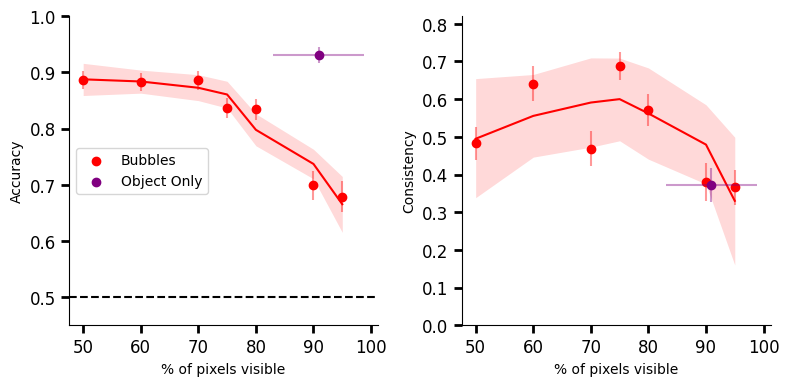

In [50]:
#Figure 1C-D
plt.figure(figsize=(8,4))
# ----------------------- RED (bubbles) -----------------------
x = np.array([100 - v for v in [5, 10, 20, 25, 30, 40, 50]], float)

# left: Accuracy
plt.subplot(1,2,1)
for v, bubbles_v in enumerate([5, 10, 20, 25, 30, 40, 50]):
    plt.scatter(100-bubbles_v, accuracies_bubbles[v], color="red", label="Bubbles" if v==0 else None)
    plt.errorbar(100-bubbles_v, accuracies_bubbles[v],
                 yerr=accuracies_bubbles_std[v]/np.sqrt(40),
                 color="red", alpha=0.4)

y = np.array(accuracies_bubbles)

yerr = np.array(accuracies_bubbles_std)/np.sqrt(40)

order = np.argsort(x)
x = x[order]
y = y[order]
y_acc = y
yerr = yerr[order]
y_acc_err = yerr

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="red")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    
    Yb[b] = savgol_filter(yb, 5, 2)             

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="red", alpha=0.15, linewidth=0)

# right: Consistency
plt.subplot(1,2,2)
for v, bubbles_v in enumerate([5, 10, 20, 25, 30, 40, 50]):
    plt.scatter(100-bubbles_v, consistencies_bubbles[v]/np.sqrt(np.nanmean(reliabilities_bubbles[v]) * np.nanmean(reliability_humans_40)), color="red")
    plt.errorbar(100-bubbles_v, consistencies_bubbles[v]/np.sqrt(np.nanmean(reliabilities_bubbles[v]) * np.nanmean(reliability_humans_40)),
                 yerr=((consistencies_bubbles_el[v]+consistencies_bubbles_eh[v])/2)/np.sqrt(40),
                 color="red", alpha=0.4)

x = 100 - np.array([5, 10, 20, 25, 30, 40, 50])
y = consistencies_bubbles / np.sqrt(np.nanmean(reliabilities_bubbles) *
                                    np.nanmean(reliability_humans_40))

yerr = (np.array(consistencies_bubbles_el) + np.array(consistencies_bubbles_eh) / 2) / np.sqrt(40)
yerr = yerr / np.sqrt(np.nanmean(reliabilities_bubbles) * np.nanmean(reliability_humans_40))

order = np.argsort(x)
x, y, yerr = x[order], y[order], yerr[order]
y_cons = y
yerr_cons = yerr

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="red")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    
    Yb[b] = savgol_filter(yb, 5, 2)             

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="red", alpha=0.15, linewidth=0)

# ----------------------- Purple point (no fit) -----------------------
plt.subplot(1,2,1)
plt.scatter(np.array(percentile_object_only_all).mean(),
            accuracy_human_behavior_object_only, color="purple", label="Object Only")
plt.errorbar(np.array(percentile_object_only_all).mean(),
             accuracy_human_behavior_object_only,
             xerr=np.array(percentile_object_only_all).std(),
             yerr=accuracy_human_behavior_object_only_std/np.sqrt(40),
             color="purple", alpha=0.4)

plt.subplot(1,2,2)
plt.scatter(np.array(percentile_object_only_all).mean(),
            consistency_human_behavior_object_only/np.sqrt(np.nanmean(np.array(reliabilities_object_only)) * np.nanmean(reliability_humans_40)), color="purple")
plt.errorbar(np.array(percentile_object_only_all).mean(),
             consistency_human_behavior_object_only/np.sqrt(np.nanmean(np.array(reliabilities_object_only)) * np.nanmean(reliability_humans_40)),
             xerr=np.array(percentile_object_only_all).std(),
             yerr=((consistency_human_behavior_object_only_eh
                    + consistency_human_behavior_object_only_el)/2)/np.sqrt(40),
             color="purple", alpha=0.4)

# Labels / styling
plt.subplot(1,2,1)
plt.xlabel('% of pixels visible')
plt.ylabel('Accuracy')
plt.axhline(0.5, linestyle="--", color="black")
plt.ylim(0.45, 1.0)
plt.legend()
journal_figure()

plt.subplot(1,2,2)
plt.xlabel('% of pixels visible')
plt.ylabel('Consistency')
plt.ylim(0.0, 0.82)
journal_figure()

plt.tight_layout()

In [46]:
from scipy.stats import shapiro, wilcoxon, ttest_ind, ttest_rel, ranksums, spearmanr, pearsonr
import numpy as np

def test_normality(d1, d2):
    stats1, p1 = shapiro(d1, nan_policy="omit")
    stats2, p2 = shapiro(d2, nan_policy="omit")
    if p1 < 0.05 or p2 < 0.05:
        return 0 #not normal
    else:
        return 1
    
def print_paired_test(d1, d2, alternative="two-sided", verbose=True):
    if test_normality(d1, d2):
        stat, p = ttest_rel(d1, d2, alternative=alternative, nan_policy="omit")
        dof = len(d1) - 1
        if verbose:
            if p < 0.001:
                print(f"t({dof}) = {stat}, p < 0.001")
            else:
                print(f"t({dof}) = {stat:.3f}, p = {p:.3f}")

    else:
        stat, p = wilcoxon(d1, d2, alternative=alternative, nan_policy="omit")
        print(stat, p)
        if verbose:
            if p < 0.001:
                print(f"z = {stat}, p < 0.001")
            else:
                print(f"z = {stat:.3f}, p = {p:.3f}")
    return p

def permutation_test(
    x,
    y,
    stat_func=None,
    n_permutations=10_000,
    alternative="two-sided",
    random_state=None,
    nan_policy="omit",
    verbose=True
):
    x = np.asarray(x)
    y = np.asarray(y)

    if nan_policy not in {"omit", "propagate"}:
        raise ValueError("nan_policy must be 'omit' or 'propagate'.")

    if nan_policy == "omit":
        x = x[~np.isnan(x)]
        y = y[~np.isnan(y)]
    elif np.isnan(x).any() or np.isnan(y).any():
        return {
            "stat": np.nan,
            "pvalue": np.nan,
            "null_dist": np.full(n_permutations, np.nan),
            "alternative": alternative,
            "n_permutations": n_permutations,
        }

    if stat_func is None:
        stat_func = lambda a, b: np.mean(a) - np.mean(b)

    # observed statistic
    stat_obs = float(stat_func(x, y))

    # RNG
    rng = (
        random_state
        if isinstance(random_state, np.random.Generator)
        else np.random.default_rng(random_state)
    )

    # build null by shuffling labels
    pooled = np.concatenate([x, y])
    nx = x.size
    null = np.empty(n_permutations, dtype=float)

    for i in range(n_permutations):
        idx1 = np.random.choice(len(pooled), nx, replace=False)
        idx2 = np.random.choice(len(pooled), nx, replace=False)
        x_perm = pooled[idx1]
        y_perm = pooled[idx2]
        null[i] = stat_func(x_perm, y_perm)

    # p-value with +1 correction to avoid zeros
    if alternative == "two-sided":
        extreme = np.sum(np.abs(null) >= abs(stat_obs))
    elif alternative == "greater":
        extreme = np.sum(null >= stat_obs)
    elif alternative == "less":
        extreme = np.sum(null <= stat_obs)
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'.")

    pval = (extreme + 1) / (n_permutations + 1)

    if verbose:
        if pval < 0.001:
                print(f"D = {stat_obs:.3f}, p < 0.001")
        else:
            print(f"D = {stat_obs:.3f}, p = {pval:.3f}")

    return {
        "stat": stat_obs,
        "pvalue": pval,
        "null_dist": null,
        "alternative": alternative,
        "n_permutations": n_permutations,
    }

In [19]:
model = LinearRegression().fit(X_quad, y_acc)
beta2 = model.coef_[1]

B = 2000
rng = np.random.default_rng(0)
beta2_samples = []

for _ in range(B):
    yb = rng.normal(y_acc, y_acc_err)
    model = LinearRegression().fit(X_quad, yb)
    beta2_samples.append(model.coef_[1])

lo, hi = np.percentile(beta2_samples, [2.5, 97.5])
print(beta2, lo, hi)

model = LinearRegression().fit(X_quad, y_cons)
beta2 = model.coef_[1]

B = 2000
rng = np.random.default_rng(0)
beta2_samples = []

for _ in range(B):
    yb = rng.normal(y_cons, yerr_cons)
    model = LinearRegression().fit(X_quad, yb)
    beta2_samples.append(model.coef_[1])

lo, hi = np.percentile(beta2_samples, [2.5, 97.5])
print(beta2, lo, hi)

-0.00017156331496223298 -0.0002484646188037535 -9.958390335857479e-05
-0.00033535346397413747 -0.000665874559196042 -2.338342217161874e-05


In [71]:
consistencies_bubbles = []
consistencies_bubbles_el = []
consistencies_bubbles_eh = []
reliabilities_bubbles = np.zeros((7, 50))+np.nan
accuracies_bubbles = []
accuracies_bubbles_std = []
for v, bubbles_v in enumerate([5, 10, 20, 30, 40, 50]):
    human_behavior_bubbles = pd.read_csv(f"{base_dir}/psychophysics/bubbles/bubbleTest{bubbles_v}_human_data.csv")
    i1_human_behavior_bubbles = calculate_i1(human_behavior_bubbles, key="image_num")

    i1_human_behavior_bubbles_ = fisher_transform(i1_human_behavior_bubbles)

    consistency_human_behavior_bubbles, el, eh = spearman_ci_boot(i1_human_behavior_bubbles_, i1_humans_40_)
    consistencies_bubbles.append(consistency_human_behavior_bubbles)
    consistencies_bubbles_el.append(el)
    consistencies_bubbles_eh.append(eh)
    accuracies_bubbles.append(i1_human_behavior_bubbles.mean())
    accuracies_bubbles_std.append(i1_human_behavior_bubbles.std())

    for rep in range(50):
        r, _, _ = split_half_reliability(human_behavior_bubbles, key="image_num")
        reliabilities_bubbles[v, rep] = r

In [47]:
xb_blue = np.array([50, 60, 70, 80, 90, 95], float)
yblue_accs = np.zeros((6))
yerr_blue_acc = np.zeros((6))
yblue_corrs = np.zeros((6))
yerr_blue_corr = np.zeros((6))
for idx, x in enumerate(xb_blue):

    csv = pd.read_csv(f"{base_dir}/psychophysics/human_data_convnext/pemi_convnext_prctile_human_dataconvnext_NoiseTunnel_Saliency_{int(x)}.csv")
    i1 = calculate_i1(csv, key="image_num")
    i1_ = fisher_transform(i1)
    consistency, el, eh = spearman_ci_boot(i1_, i1_humans_40_)
    reliabilities = []
    for r in range(10):
        reliability, _, _ = split_half_reliability(csv, key="image_num")
        reliabilities.append(reliability)
    accuracv = i1.mean()
    accuracv_std = i1.std()
    yblue_accs[idx] =accuracv
    yerr_blue_acc[idx] = accuracv_std/np.sqrt(40)
    yblue_corrs[idx] = consistency/np.sqrt(np.mean(reliabilities)*np.mean(reliability_humans_40))
    yerr_blue_corr[idx] = ((eh+el)/2)/np.sqrt(40)

all_i1 = []

for idx, x in enumerate(xb_blue):
    csv = pd.read_csv(f"{base_dir}/psychophysics/human_data_convnext/pemi_convnext_prctile_human_dataconvnext_NoiseTunnel_Saliency_{int(x)}.csv")
    i1 = calculate_i1(csv, key="image_num")
    all_i1.append(i1)

all_i1 = np.stack(all_i1, axis=0)   # shape: (7 visibility levels, n_images)
n_levels, n_images = all_i1.shape

print("all_i1 shape:", all_i1.shape)


results = evaluate_split_half_models(all_i1, xb_blue, n_splits=500, seed=0)

for name, vals in results.items():
    vals = np.asarray(vals, dtype=float)
    print(
        f"{name:12s} | mean test R2 = {np.nanmean(vals):.4f} "
        f"| median = {np.nanmedian(vals):.4f} "
        f"| 95% CI = [{np.nanpercentile(vals, 2.5):.4f}, {np.nanpercentile(vals, 97.5):.4f}]"
    )

np.nanmean(results['constant']), np.nanstd(results['constant']), np.nanmean(results['linear']), np.nanstd(results['linear']), np.nanmean(results['inv_sigmoid']), np.nanstd(results['inv_sigmoid'])
print_paired_test(results['inv_sigmoid'], results['linear']), permutation_test(results['inv_sigmoid'], results['linear'])

all_i1 shape: (6, 40)


/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))


constant     | mean test R2 = -1.3716 | median = -0.4775 | 95% CI = [-7.2295, -0.0009]
linear       | mean test R2 = -1.1924 | median = -0.2966 | 95% CI = [-7.7420, 0.5455]
inv_sigmoid  | mean test R2 = -0.9401 | median = -0.0640 | 95% CI = [-7.7460, 0.8458]
11444.0 1.8102024841841727e-56
z = 11444.0, p < 0.001
D = 0.252, p = 0.144


(np.float64(1.8102024841841727e-56),
 {'stat': 0.2523021962888917,
  'pvalue': np.float64(0.1441855814418558),
  'null_dist': array([ 0.08220083, -0.03499099,  0.06591657, ..., -0.18262253,
          0.00152178, -0.13972133], shape=(10000,)),
  'alternative': 'two-sided',
  'n_permutations': 10000})

In [48]:
# human reference (clean images)
i1_humans = np.asarray(i1_humans_40_, dtype=float)

n_levels, n_images = all_i1.shape


# -----------------------------
# Consistency computation
# -----------------------------
def compute_consistency_curve(i1_bubbles, i1_ref, idx):
    y = []
    for v in range(i1_bubbles.shape[0]):
        r, _ = spearmanr(i1_bubbles[v, idx], i1_ref[idx])
        y.append(r)
    return np.array(y)


# -----------------------------
# Split-half evaluation
# -----------------------------
def evaluate_consistency_models(all_i1_bubbles, i1_ref, xvals, n_splits=200, seed=0):
    rng = np.random.default_rng(seed)

    results = {
        "constant": [],
        "linear": [],
        "inv_sigmoid": [],
    }

    n_images = all_i1_bubbles.shape[1]

    for _ in range(n_splits):
        perm = rng.permutation(n_images)
        train_idx = perm[: n_images // 2]
        test_idx  = perm[n_images // 2 :]

        y_train = compute_consistency_curve(all_i1_bubbles, i1_ref, train_idx)
        y_test  = compute_consistency_curve(all_i1_bubbles, i1_ref, test_idx)

        try:
            _, f = fit_constant(xvals, y_train)
            results["constant"].append(r2_score(y_test, f(xvals)))
        except:
            results["constant"].append(np.nan)

        try:
            _, f = fit_linear(xvals, y_train)
            results["linear"].append(r2_score(y_test, f(xvals)))
        except:
            results["linear"].append(np.nan)

        try:
            _, f = fit_inv_sigmoid(xvals, y_train)
            results["inv_sigmoid"].append(r2_score(y_test, f(xvals)))
        except:
            results["inv_sigmoid"].append(np.nan)

    return results


# -----------------------------
# Run
# -----------------------------
results = evaluate_consistency_models(
    all_i1,
    i1_humans,
    xb_blue,
    n_splits=500,
    seed=0
)

for name, vals in results.items():
    vals = np.asarray(vals)
    print(
        f"{name:12s} | mean R2 = {np.nanmean(vals):.4f} "
        f"| median = {np.nanmedian(vals):.4f} "
        f"| 95% CI = [{np.nanpercentile(vals,2.5):.4f}, {np.nanpercentile(vals,97.5):.4f}]"
    )

/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + 

constant     | mean R2 = -3.1938 | median = -1.0500 | 95% CI = [-20.3935, -0.0022]
linear       | mean R2 = -3.8705 | median = -1.4261 | 95% CI = [-24.5810, 0.2491]
inv_sigmoid  | mean R2 = -4.2431 | median = -1.6533 | 95% CI = [-25.1707, 0.2873]


/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))
/tmp/ipykernel_3350735/429858435.py:22: RuntimeWarning: overflow encountered in exp
  return a + b / (1.0 + np.exp((x - c) / d))


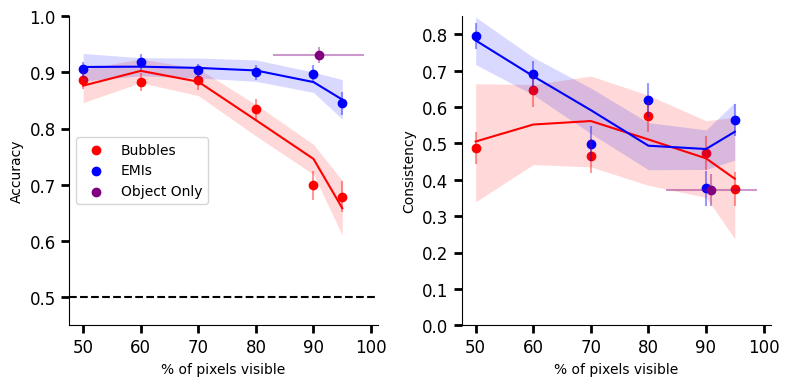

In [73]:
#Figure 6D-E
plt.figure(figsize=(8,4))
# ----------------------- RED (bubbles) -----------------------
x = np.array([100 - v for v in [5, 10, 20, 30, 40, 50]], float)

# left: Accuracy
plt.subplot(1,2,1)
for v, bubbles_v in enumerate([5, 10, 20, 30, 40, 50]):
    plt.scatter(100-bubbles_v, accuracies_bubbles[v], color="red", label="Bubbles" if v==0 else None)
    plt.errorbar(100-bubbles_v, accuracies_bubbles[v],
                 yerr=accuracies_bubbles_std[v]/np.sqrt(40),
                 color="red", alpha=0.4)

y = np.array(accuracies_bubbles)

yerr = np.array(accuracies_bubbles_std)/np.sqrt(40)

order = np.argsort(x)
x = x[order]
y = y[order]
yerr = yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="red")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    
    Yb[b] = savgol_filter(yb, 5, 2)             

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="red", alpha=0.15, linewidth=0)

# right: Consistency
plt.subplot(1,2,2)
for v, bubbles_v in enumerate([5, 10, 20, 30, 40, 50]):
    plt.scatter(100-bubbles_v, consistencies_bubbles[v]/np.sqrt(np.nanmean(reliabilities_bubbles[v]) * np.nanmean(reliability_humans_40)), color="red")
    plt.errorbar(100-bubbles_v, consistencies_bubbles[v]/np.sqrt(np.nanmean(reliabilities_bubbles[v]) * np.nanmean(reliability_humans_40)),
                 yerr=((consistencies_bubbles_el[v]+consistencies_bubbles_eh[v])/2)/np.sqrt(40),
                 color="red", alpha=0.4)

x = 100 - np.array([5, 10, 20, 30, 40, 50])
y = consistencies_bubbles / np.sqrt(np.nanmean(reliabilities_bubbles) *
                                    np.nanmean(reliability_humans_40))

yerr = (np.array(consistencies_bubbles_el) + np.array(consistencies_bubbles_eh) / 2) / np.sqrt(40)
yerr = yerr / np.sqrt(np.nanmean(reliabilities_bubbles) * np.nanmean(reliability_humans_40))

order = np.argsort(x)
x, y, yerr = x[order], y[order], yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="red")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    
    Yb[b] = savgol_filter(yb, 5, 2)             

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="red", alpha=0.15, linewidth=0)

# ----------------------- BLUE (EMIs) -----------------------

# # left: Accuracy
plt.subplot(1,2,1)

plt.scatter(xb_blue, yblue_accs, color="blue", label="EMIs")
plt.errorbar(xb_blue, yblue_accs,
                yerr=yerr_blue_acc,
                color="blue", alpha=0.4, linestyle="None")

x = xb_blue
y = yblue_accs
yerr = yerr_blue_acc

order = np.argsort(x)
x = x[order]
y = y[order]
yerr = yerr[order]
y_acc = y
y_acc_err = yerr

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="blue")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    # resample points
    Yb[b] = savgol_filter(yb, 5, 2)             # refit smoother

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="blue", alpha=0.15, linewidth=0)

plt.subplot(1,2,2)

plt.scatter(xb_blue, yblue_corrs, color="blue")
plt.errorbar(xb_blue, yblue_corrs,
                yerr=yerr_blue_corr,
                color="blue", alpha=0.4, linestyle="None")

x = xb_blue
y = yblue_corrs

yerr = yerr_blue_corr

order = np.argsort(x)
x = x[order]
y = y[order]
yerr = yerr[order]

y_cons = y
y_cons_err = yerr

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="blue")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    
    Yb[b] = savgol_filter(yb, 5, 2)             

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="blue", alpha=0.15, linewidth=0)


# ----------------------- PURPLE point (object only) -----------------------
plt.subplot(1,2,1)
plt.scatter(np.array(percentile_object_only_all).mean(),
            accuracy_human_behavior_object_only, color="purple", label="Object Only")
plt.errorbar(np.array(percentile_object_only_all).mean(),
             accuracy_human_behavior_object_only,
             xerr=np.array(percentile_object_only_all).std(),
             yerr=accuracy_human_behavior_object_only_std/np.sqrt(40),
             color="purple", alpha=0.4)

plt.subplot(1,2,2)
plt.scatter(np.array(percentile_object_only_all).mean(),
            consistency_human_behavior_object_only/np.sqrt(np.nanmean(np.array(reliabilities_object_only)) * np.nanmean(reliability_humans_40)), color="purple")
plt.errorbar(np.array(percentile_object_only_all).mean(),
             consistency_human_behavior_object_only/np.sqrt(np.nanmean(np.array(reliabilities_object_only)) * np.nanmean(reliability_humans_40)),
             xerr=np.array(percentile_object_only_all).std(),
             yerr=((consistency_human_behavior_object_only_eh
                    + consistency_human_behavior_object_only_el)/2)/np.sqrt(40),
             color="purple", alpha=0.4)

# Labels / styling
plt.subplot(1,2,1)
plt.xlabel('% of pixels visible')
plt.ylabel('Accuracy')
plt.axhline(0.5, linestyle="--", color="black")
plt.ylim(0.45, 1.0)
plt.legend()
journal_figure()

plt.subplot(1,2,2)
plt.xlabel('% of pixels visible')
plt.ylabel('Consistency')
plt.ylim(0.0, 0.85)
journal_figure()

plt.tight_layout()


In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error

def loo_mse(X, y):
    loo = LeaveOneOut()
    errs = []
    all_y_pred = []
    for train, test in loo.split(X):
        model = LinearRegression().fit(X[train], y[train])
        y_pred = model.predict(X[test])
        errs.append((y[test] - y_pred)**2)
        all_y_pred.append(y_pred)
    return errs, all_y_pred

# Prepare data
X_lin = x.reshape(-1,1)
X_quad = np.column_stack([x, x**2])
X_const = np.ones((len(x),1))

mse_lin, y_pred_lin = loo_mse(X_lin, y_acc)
mse_quad, y_pred_quad = loo_mse(X_quad, y_acc)
mse_const, y_pred_const = loo_mse(X_const, y_acc)

print("Acc LOO MSE const:", np.mean(mse_const), np.std(mse_const))
print("Acc LOO MSE lin:", np.mean(mse_lin), np.std(mse_lin))
print("Acc LOO MSE quad:", np.mean(mse_quad), np.std(mse_quad))
permutation_test(np.array(mse_quad), np.array(mse_lin), alternative="less")

mse_lin, y2_pred_lin = loo_mse(X_lin, y_cons)
mse_quad, y2_pred_quad = loo_mse(X_quad, y_cons)
mse_const, y2_pred_const = loo_mse(X_const, y_cons)

print("Cons LOO MSE const:", np.mean(mse_const), np.std(mse_const))
print("Cons LOO MSE lin:", np.mean(mse_lin), np.std(mse_lin))
permutation_test(np.array(mse_const), np.array(mse_lin), alternative="less")
print("Cons LOO MSE quad:", np.mean(mse_quad), np.std(mse_quad))
permutation_test(np.array(mse_quad), np.array(mse_lin))

model = LinearRegression().fit(X_quad, y_acc)
beta2 = model.coef_[1]

B = 2000
rng = np.random.default_rng(0)
beta2_samples = []

for _ in range(B):
    yb = rng.normal(y_acc, y_acc_err)
    model = LinearRegression().fit(X_quad, yb)
    beta2_samples.append(model.coef_[1])

lo, hi = np.percentile(beta2_samples, [2.5, 97.5])
print(beta2, lo, hi)

model = LinearRegression().fit(X_quad, y_cons)
beta2 = model.coef_[1]

B = 2000
rng = np.random.default_rng(0)
beta2_samples = []

for _ in range(B):
    yb = rng.normal(y_cons, y_cons_err)
    model = LinearRegression().fit(X_quad, yb)
    beta2_samples.append(model.coef_[1])

lo, hi = np.percentile(beta2_samples, [2.5, 97.5])
print(beta2, lo, hi)

Acc LOO MSE const: 0.0007988915781657712 0.0013071245570704165
Acc LOO MSE lin: 0.0008244056003532298 0.0009024481413399906
Acc LOO MSE quad: 0.0005861971920246811 0.0007572334763387847
D = -0.000, p = 0.266
Cons LOO MSE const: 0.02585799222898814 0.02699995546484859
Cons LOO MSE lin: 0.01780269149283512 0.01305236224344685
D = 0.008, p = 0.806
Cons LOO MSE quad: 0.019025753236370315 0.013928893908166321
D = 0.001, p = 0.831
-5.824805912924269e-05 -0.00011847330204591747 4.285566208862613e-06
0.00020545915528423053 3.802174989499813e-05 0.0003810256995314911


In [14]:
xb_blue = np.array([50, 60, 70, 80, 90, 95], float)
yblue_accs_worst = np.zeros((6))
yerr_blue_acc_worst = np.zeros((6))
yblue_corrs_worst = np.zeros((6))
yerr_blue_corr_worst = np.zeros((6))
for idx, x in enumerate(xb_blue):

    csv = pd.read_csv(f"{base_dir}/psychophysics/human_data_convnext/pemi_convnext_prctile_human_dataconvnext_Deconvolution_{int(x)}.csv")
    i1 = calculate_i1(csv, key="image_num")
    consistency, el, eh = spearman_ci_boot(i1, i1_humans_40_)
    reliabilities = []
    for r in range(10):
        reliability, _, _ = split_half_reliability(csv, key="image_num")
        reliabilities.append(reliability)
    accuracv = i1.mean()
    accuracv_std = i1.std()
    yblue_accs_worst[idx] =accuracv
    yerr_blue_acc_worst[idx] = accuracv_std/np.sqrt(40)
    yblue_corrs_worst[idx] = consistency/np.sqrt(np.mean(reliabilities)*np.mean(reliability_humans_40))
    yerr_blue_corr_worst[idx] = ((eh+el)/2)/np.sqrt(40)

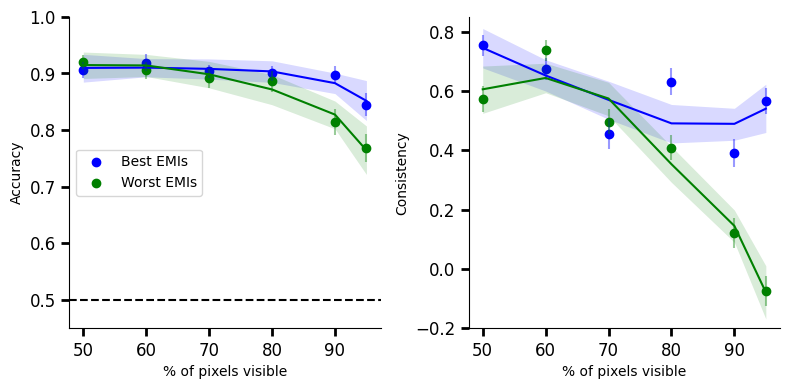

In [15]:
#Figure S7
plt.figure(figsize=(8,4))

# ----------------------- BLUE (percentiles) -----------------------
# left: Accuracy
plt.subplot(1,2,1)

plt.scatter(xb_blue, yblue_accs, color="blue", label="Best EMIs")
plt.errorbar(xb_blue, yblue_accs,
                yerr=yerr_blue_acc,
                color="blue", alpha=0.4, linestyle="None")

x = xb_blue
y = yblue_accs

# pointwise y-errors you used for the error bars (propagate the same normalization)
yerr = yerr_blue_acc

order = np.argsort(x)
x = x[order]
y = y[order]
yerr = yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="blue")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    # resample points
    Yb[b] = savgol_filter(yb, 5, 2)             # refit smoother

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="blue", alpha=0.15, linewidth=0)

# right: Consistency (FIX: index i was wrongly using v before)
plt.subplot(1,2,2)

plt.scatter(xb_blue, yblue_corrs, color="blue")
plt.errorbar(xb_blue, yblue_corrs,
                yerr=yerr_blue_corr,
                color="blue", alpha=0.4, linestyle="None")

x = xb_blue
y = yblue_corrs

# pointwise y-errors you used for the error bars (propagate the same normalization)
yerr = yerr_blue_corr

order = np.argsort(x)
x = x[order]
y = y[order]
yerr = yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="blue")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    # resample points
    Yb[b] = savgol_filter(yb, 5, 2)             # refit smoother

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="blue", alpha=0.15, linewidth=0)


plt.subplot(1,2,1)

plt.scatter(xb_blue, yblue_accs_worst, color="green", label="Worst EMIs")
plt.errorbar(xb_blue, yblue_accs_worst,
                yerr=yerr_blue_acc_worst,
                color="green", alpha=0.4, linestyle="None")

x = xb_blue
y = yblue_accs_worst

# pointwise y-errors you used for the error bars (propagate the same normalization)
yerr = yerr_blue_acc_worst

order = np.argsort(x)
x = x[order]
y = y[order]
yerr = yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="green")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    # resample points
    Yb[b] = savgol_filter(yb, 5, 2)             # refit smoother

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="green", alpha=0.15, linewidth=0)

# right: Consistency (FIX: index i was wrongly using v before)
plt.subplot(1,2,2)

plt.scatter(xb_blue, yblue_corrs_worst, color="green")
plt.errorbar(xb_blue, yblue_corrs_worst,
                yerr=yerr_blue_corr_worst,
                color="green", alpha=0.4, linestyle="None")

x = xb_blue
y = yblue_corrs_worst

# pointwise y-errors you used for the error bars (propagate the same normalization)
yerr = yerr_blue_corr_worst

order = np.argsort(x)
x = x[order]
y = y[order]
yerr = yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="green")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    # resample points
    Yb[b] = savgol_filter(yb, 5, 2)             # refit smoother

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="green", alpha=0.15, linewidth=0)

# Labels / styling
plt.subplot(1,2,1)
plt.xlabel('% of pixels visible')
plt.ylabel('Accuracy')
plt.axhline(0.5, linestyle="--", color="black")
plt.ylim(0.45, 1.0)
plt.legend()
journal_figure()

plt.subplot(1,2,2)
plt.xlabel('% of pixels visible')
plt.ylabel('Consistency')
plt.ylim(-0.2, 0.85)
journal_figure()

plt.tight_layout()


In [16]:
percentiles = np.array([50, 60, 70, 80, 90, 95])
accs_p = np.zeros((1, len(percentiles)))+np.nan
accs_p_err = np.zeros((1, len(percentiles)))+np.nan
corrs_p = np.zeros((1, len(percentiles)))+np.nan
corrs_p_err = np.zeros((1, len(percentiles)))+np.nan

accs_p_worst = np.zeros((1, len(percentiles)))+np.nan
accs_p_worst_err = np.zeros((1, len(percentiles)))+np.nan
corrs_p_worst = np.zeros((1, len(percentiles)))+np.nan
corrs_p_worst_err = np.zeros((1, len(percentiles)))+np.nan

# for r in range(20):
for p_idx, p in enumerate(percentiles):
    response_dir = f'{base_dir}/behavioral_responses/convnext/NoiseTunnel_Saliency'
    i1_file_ref = f'{response_dir}/{p}/convnext_i1.json'
    
    with open(i1_file_ref, 'r') as f:
        i1_scores_ref = json.load(f)
    
    i1_20 = np.array(i1_scores_ref['target_pEMI'])[all_selected_indices]
    i1_20_ = fisher_transform(i1_20)

    accs_p[0,p_idx] = i1_20.mean()
    accs_p_err[0,p_idx] = i1_20.std()/np.sqrt(len(i1_20))

    corr, el, eh = spearman_ci_boot(i1_20_, i1_humans_40_)

    corrs_p[0,p_idx] = corr/np.sqrt(np.nanmean(reliability_humans_40))
    corrs_p_err[0,p_idx] = (el+eh)/2

    response_dir = f'{base_dir}/behavioral_responses/convnext/Deconvolution'
    i1_file_ref = f'{response_dir}/{p}/convnext_i1.json'

    with open(i1_file_ref, 'r') as f:
        i1_scores_ref = json.load(f)
    
    i1_20 = np.array(i1_scores_ref['target_pEMI'])[all_selected_indices]
    i1_20_ = fisher_transform(i1_20)

    accs_p_worst[0,p_idx] = i1_20.mean()
    accs_p_worst_err[0,p_idx] = i1_20.std()/np.sqrt(len(i1_20))

    corr, el, eh = spearman_ci_boot(i1_20_, i1_humans_40_)

    corrs_p_worst[0,p_idx] = corr/np.sqrt(np.nanmean(reliability_humans_40))
    corrs_p_worst_err[0,p_idx] = (el+eh)/2

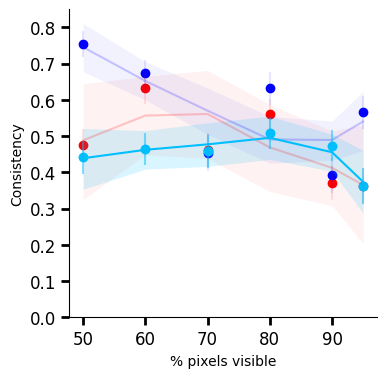

In [17]:
#Figure 6F
plt.figure(figsize=(10, 4))

# ----------------------- RED (bubbles) -----------------------
xb_red = np.array([100 - v for v in [5, 10, 20, 30, 40, 50]], float)

# Consistency
for v, bubbles_v in enumerate([5, 10, 20, 30, 40, 50]):
    plt.scatter(100-bubbles_v, consistencies_bubbles[v]/np.sqrt(np.nanmean(reliabilities_bubbles[v]) * np.nanmean(reliability_humans_40)), color="red")
    plt.errorbar(100-bubbles_v, consistencies_bubbles[v]/np.sqrt(np.nanmean(reliabilities_bubbles[v]) * np.nanmean(reliability_humans_40)),
                 yerr=((consistencies_bubbles_el[v]+consistencies_bubbles_eh[v])/2)/np.sqrt(40),
                 color="red", alpha=0.1)

x = 100 - np.array([5, 10, 20, 30, 40, 50])
y = consistencies_bubbles / np.sqrt(np.nanmean(reliabilities_bubbles) *
                                    np.nanmean(reliability_humans_40))

yerr = (np.array(consistencies_bubbles_el) + np.array(consistencies_bubbles_eh) / 2) / np.sqrt(40)
yerr = yerr / np.sqrt(np.nanmean(reliabilities_bubbles) * np.nanmean(reliability_humans_40))

order = np.argsort(x)
x, y, yerr = x[order], y[order], yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="red", alpha=0.2)

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                   
    Yb[b] = savgol_filter(yb, 5, 2)            

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="red", alpha=0.05, linewidth=0)

plt.scatter(xb_blue, yblue_corrs, color="blue")
plt.errorbar(xb_blue, yblue_corrs,
                yerr=yerr_blue_corr,
                color="blue", alpha=0.1, linestyle="None")

x = xb_blue
y = yblue_corrs

# pointwise y-errors you used for the error bars (propagate the same normalization)
yerr = yerr_blue_corr

order = np.argsort(x)
x = x[order]
y = y[order]
yerr = yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="blue", alpha=0.2)

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    # resample points
    Yb[b] = savgol_filter(yb, 5, 2)             # refit smoother

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="blue", alpha=0.05, linewidth=0)

plt.scatter(np.array(percentiles, dtype=float), (np.nanmean(corrs_p, axis=0)/np.sqrt(np.nanmean(reliability_humans_40))), marker='o', color='deepskyblue')
plt.errorbar(np.array(percentiles, dtype=float), (np.nanmean(corrs_p, axis=0)/np.sqrt(np.nanmean(reliability_humans_40))), yerr=np.nanmean(corrs_p_err, axis=0)/np.sqrt(40), marker='o', color='deepskyblue', linestyle="None", alpha=0.5)

x = np.array(percentiles, dtype=float)
y = (np.nanmean(corrs_p, axis=0)/np.sqrt(np.nanmean(reliability_humans_40)))

# pointwise y-errors you used for the error bars (propagate the same normalization)
yerr = np.nanmean(corrs_p_err, axis=0)/np.sqrt(40)

order = np.argsort(x)
x = x[order]
y = y[order]
yerr = yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="deepskyblue")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    # resample points
    Yb[b] = savgol_filter(yb, 5, 2)             # refit smoother

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="deepskyblue", alpha=0.15, linewidth=0)

plt.xlabel("% pixels visible")
plt.ylabel("Consistency")
plt.ylim(0, 0.85)
journal_figure()

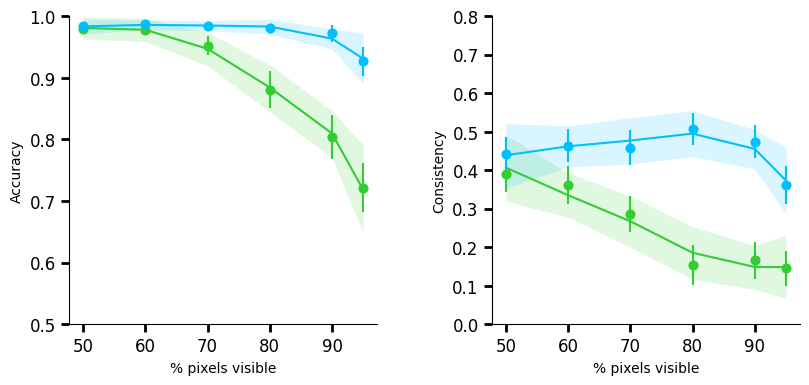

In [18]:
#Figure S8
plt.figure(figsize=(10, 4))

ax1 = plt.subplot(1, 2, 1)
x = np.array(percentiles, dtype=float)
y = accs_p_worst.mean(axis=0)
yerr = accs_p_worst_err.mean(axis=0)
plt.scatter(x, y, marker='o', color='limegreen')
plt.errorbar(x, y, yerr=yerr, marker='o', color='limegreen', linestyle="None")


order = np.argsort(x)
x = x[order]
y = y[order]
yerr = yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="limegreen")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    # resample points
    Yb[b] = savgol_filter(yb, 5, 2)             # refit smoother

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="limegreen", alpha=0.15, linewidth=0)

ax1 = plt.subplot(1, 2, 1)
y = accs_p.mean(axis=0)
yerr = accs_p_err.mean(axis=0)
plt.scatter(x, y, marker='o', color='deepskyblue')
plt.errorbar(x, y, yerr=yerr, marker='o', color='deepskyblue', linestyle="None")

y = y[order]
yerr = yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="deepskyblue")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    # resample points
    Yb[b] = savgol_filter(yb, 5, 2)             # refit smoother

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="deepskyblue", alpha=0.15, linewidth=0)

plt.xlabel("% pixels visible")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)
journal_figure()

ax = plt.subplot(1, 2, 2)
y = (np.nanmean(corrs_p_worst, axis=0)/np.sqrt(np.nanmean(reliability_humans_40)))
yerr = (np.nanmean(corrs_p_worst_err, axis=0)/np.sqrt(40))
plt.scatter(x, y, marker='o', color='limegreen')
plt.errorbar(x, y, yerr=yerr, marker='o', color='limegreen', linestyle="None")

y = y[order]
yerr = yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="limegreen")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    # resample points
    Yb[b] = savgol_filter(yb, 5, 2)             # refit smoother

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="limegreen", alpha=0.15, linewidth=0)

y = (np.nanmean(corrs_p, axis=0)/np.sqrt(np.nanmean(reliability_humans_40)))
yerr = (np.nanmean(corrs_p_err, axis=0)/np.sqrt(40))
plt.scatter(x, y, marker='o', color='deepskyblue')
plt.errorbar(x, y, yerr=yerr, marker='o', color='deepskyblue', linestyle="None")

y = y[order]
yerr = yerr[order]

y_fit = savgol_filter(y, window_length=5, polyorder=2)
plt.plot(x, y_fit, color="deepskyblue")

B = 2000
rng = np.random.default_rng(0)
Yb = np.empty((B, len(x)))
for b in range(B):
    yb = rng.normal(y, yerr)                    # resample points
    Yb[b] = savgol_filter(yb, 5, 2)             # refit smoother

lo, hi = np.percentile(Yb, [2.5, 97.5], axis=0)

plt.fill_between(x, lo, hi, color="deepskyblue", alpha=0.15, linewidth=0)

plt.xlabel("% pixels visible")
plt.ylabel("Consistency")
plt.ylim(0.0, 0.8)
journal_figure()
